In [3]:
pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 6.3 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.1 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.2 MB 9.1 MB/s eta 0:00:01
   -------------- ------------------------- 2.9/8.2 MB 9.6 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.2 MB 7.2 MB/s eta 0:00:01
   ------------------------ --------------- 5.0/8.2 MB 6.4 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.2 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 6.8/8.2 MB 4.6 MB/s eta 0:00:01
   ------------------------------------- -- 7.6/8.2 MB 4.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 4.3 MB/s eta 0:00:01
   --------------------------

  You can safely remove it manually.
  You can safely remove it manually.


In [4]:
import mlxtend
print(mlxtend.__version__)

0.25.0


In [6]:
!pip install textblob

   ---------------------------------------- 0.0/625.0 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/625.0 kB ? eta -:--:--
   ---------------------------------------- 625.0/625.0 kB 3.2 MB/s  0:00:00


In [9]:
from textblob import TextBlob
text = TextBlob("This product is amazing")
print(text.sentiment)

Sentiment(polarity=0.6000000000000001, subjectivity=0.9)


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import mlxtend
from textblob import TextBlob

print("All Libraries installed successfully!")

All Libraries installed successfully!


## Load the Dataset :

In [11]:
import pandas as pd
df =pd.read_csv("groceries.csv.csv")

print("Shape:",df.shape)
print("\nColumns:")
print(df.columns)

df.head()

Shape: (38765, 3)

Columns:
Index(['Member_number', 'Date', 'itemDescription'], dtype='object')


,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


## Eplore Dataset :

In [13]:
#check first 10 rows:
df.head()

#check missing values:
print("\nMissing Values:")
print(df.isnull().sum())

#Number off unique customers:
print("\nUnique Customers:")
print(df["Member_number"].nunique())

#Number of unique products:
print("\nUnique Products:")
print(df["itemDescription"].nunique())


Missing Values:
Member_number      0
Date               0
itemDescription    0
dtype: int64

Unique Customers:
3898

Unique Products:
167


## Create Transactions :

In [14]:
# Create Transaction list :

transactions =(
    df.groupby(['Member_number','Date',])
['itemDescription']
    .apply(list)
    .tolist()
)

print("Total Transactions:", len(transactions))
print("\nSample Transactions:")
print(transactions[:5])

Total Transactions: 14963

Sample Transactions:
[['sausage', 'whole milk', 'semi-finished bread', 'yogurt'], ['whole milk', 'pastry', 'salty snack'], ['canned beer', 'misc. beverages'], ['sausage', 'hygiene articles'], ['soda', 'pickled vegetables']]


##  Install Transaction Encoder :

In [15]:
from mlxtend.preprocessing import TransactionEncoder

## Convert Transactions into Basket Formate :

In [16]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket = pd.DataFrame(te_array, columns=te.columns_)

print(basket.shape)
basket.head()

(14963, 167)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Run the Apriori Algorithm :

In [24]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(
    basket,
    min_support=0.003,
    use_colnames=True
)

frequent_itemsets.sort_values(
    by="support",
    ascending=False
).head(20)


# It finds products that appear in at least 1% of all transactions.

,support,itemsets
108,0.157923,(whole milk)
67,0.122101,(other vegetables)
82,0.110005,(rolls/buns)
91,0.097106,(soda)
109,0.085879,(yogurt)
83,0.069572,(root vegetables)
101,0.067767,(tropical fruit)
7,0.060683,(bottled water)
86,0.060349,(sausage)
22,0.053131,(citrus fruit)


## Generate Association Rules :

In [25]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.1
)

rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(whole milk),0.033950,0.157923,0.004678,0.137795,0.872548,1.0,-0.000683,0.976656,-0.131343,0.024991,-0.023902,0.083709
1,(bottled beer),(other vegetables),0.045312,0.122101,0.004678,0.103245,0.845568,1.0,-0.000854,0.978973,-0.160585,0.028747,-0.021479,0.070780
2,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-0.000005,0.999874,-0.000702,0.036469,-0.000126,0.101549
3,(bottled water),(whole milk),0.060683,0.157923,0.007151,0.117841,0.746196,1.0,-0.002432,0.954564,-0.265842,0.033818,-0.047598,0.081561
4,(brown bread),(whole milk),0.037626,0.157923,0.004478,0.119005,0.753566,1.0,-0.001464,0.955825,-0.253625,0.023435,-0.046216,0.073680


## Find the Best Rule :

In [26]:
rules = rules.sort_values(
    by="confidence",
    ascending=False
)

rules[['antecedents',
       'consequents',
       'support',
       'confidence',
       'lift']].head(20)

,antecedents,consequents,support,confidence,lift
2,(bottled beer),(whole milk),0.007151,0.157817,0.999330
32,(sausage),(whole milk),0.008955,0.148394,0.939663
21,(newspapers),(whole milk),0.005614,0.144330,0.913926
12,(domestic eggs),(whole milk),0.005280,0.142342,0.901341
19,(hamburger meat),(whole milk),0.003074,0.140673,0.890769
14,(frankfurter),(whole milk),0.005280,0.139823,0.885388
0,(beef),(whole milk),0.004678,0.137795,0.872548
13,(frankfurter),(other vegetables),0.005146,0.136283,1.116150
16,(frozen vegetables),(whole milk),0.003809,0.136038,0.861422
29,(pork),(whole milk),0.005012,0.135135,0.855703


## Creating Visualization :

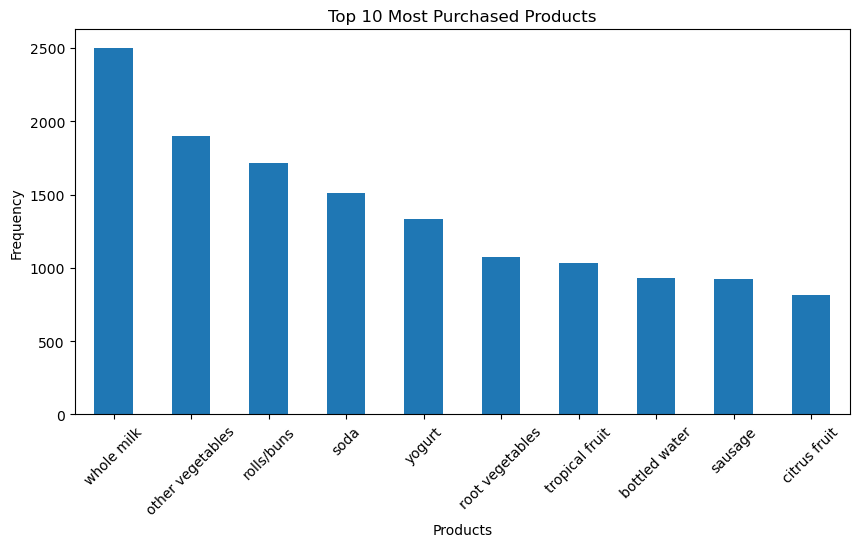

In [29]:
import matplotlib.pyplot as plt

top_products = (
    df['itemDescription']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,5))
top_products.plot(kind='bar')

plt.title('Top 10 Most Purchased Products')
plt.xlabel('Products')
plt.ylabel('Frequency')

plt.savefig("top_products.png",bbox_inches="tight")
plt.xticks(rotation=45)
plt.show()

# Conclusion

The Market Basket Analysis identified frequently purchased products and relationships between products.

Key Findings:
- Whole Milk is the most frequently purchased product.
- Other Vegetables and Rolls/Buns are among the top-selling products.
- Several products show strong purchasing associations with Whole Milk.
- Customers tend to purchase complementary grocery items together.

Business Recommendations:
1. Place associated products close together in stores.
2. Create product bundles and combo offers.
3. Use association rules for cross-selling opportunities.
4. Improve promotional campaigns based on buying patterns.
5. Optimize inventory for frequently purchased products.